### Produce some plots for trajectory analysis

In [11]:
import pandas as pd
import numpy as np
import trajectory_funcs as funcs
import scanpy as sc
import scipy
from scipy import sparse
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [45]:
plots_dir = "plots/"

In [7]:
sc._settings.settings._vector_friendly=True
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [92]:
def visualize_gene_trajectory(
    adata, gene, other_state, trajectory_key="traj_score", frac=0.2, ylim=None):
    '''Visualize gene trajectory along density gradient (log-scaled expression).'''

    # extract expression
    y = (
        adata[:, gene].X.toarray().ravel()
        if scipy.sparse.issparse(adata.X)
        else adata[:, gene].X.ravel()
    )

    # log-transform (safe for zeros)
    y_log = np.log1p(y)

    traj = adata.obs[trajectory_key].values

    # perform LOWESS on log scale
    lowess = sm.nonparametric.lowess(y_log, traj, frac=frac)

    # plot
    plt.figure(figsize=(5, 4))
    plt.title(gene)
    plt.scatter(traj, y_log, s=4, alpha=0.3, rasterized=True)
    plt.plot(lowess[:, 0], lowess[:, 1], color="red", linewidth=2)

    plt.xlabel(f"ND → {other_state} density trajectory")
    plt.ylabel(f"log1p({gene} expression)")

    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    return plt

#### Run developmental trajectory for Cardiomyocytes

In [3]:
%%time
cell_type = "Cardiomyocyte"
adata = sc.read_h5ad("../subclustering_analysis/continuous_cov_corrected_no_scvi/" + cell_type + ".h5ad")
adata_metadata = pd.read_csv("../subclustering_analysis/post_subcluster_annotation/" + cell_type + 
                             "_annotation.csv", index_col=0)
adata.obs = adata_metadata

<timed exec>:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: user 4min 20s, sys: 37.3 s, total: 4min 58s
Wall time: 6min 10s


In [20]:
%%time
non_diseased_group = "fetal:ND"
other_group = "postnatal:ND"
max_cells_per_group = 3000

comparison_adata = funcs.perform_trajectory_analysis(adata, other_group = other_group,
                                               max_cells_per_group=max_cells_per_group, non_diseased_group=non_diseased_group)

Downsampling summary:
age_disease
fetal:ND        3000
postnatal:ND    3000
Name: count, dtype: int64
CPU times: user 40.1 s, sys: 1min 50s, total: 2min 31s
Wall time: 2min 5s


In [21]:
%%time
gene_traj_df = funcs.compute_gene_signatures_along_traj(comparison_adata)

CPU times: user 13.5 s, sys: 171 ms, total: 13.6 s
Wall time: 13.6 s


In [24]:
gene_traj_df

,gene,spearman_r,pval
8566,RIC3,0.771507,0.0
1940,AAK1,0.770911,0.0
9293,TBCEL,0.769193,0.0
9972,MYBPC1,0.767301,0.0
10045,PPTC7,0.765896,0.0
...,...,...,...
1259,ASTN1,-0.781448,0.0
2241,GPR39,-0.782467,0.0
10227,GJA3,-0.783126,0.0
4175,TRPC3,-0.788832,0.0


In [23]:
#gene_traj_df.head(50)['gene']

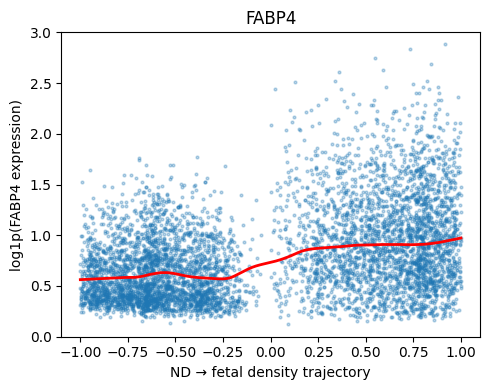

In [112]:
gene_name = "FABP4"
ND_up_plot = visualize_gene_trajectory(comparison_adata, other_state = "fetal", gene = gene_name, ylim = (0, 3))
ND_up_plot.savefig(plots_dir + gene_name + ".pdf")

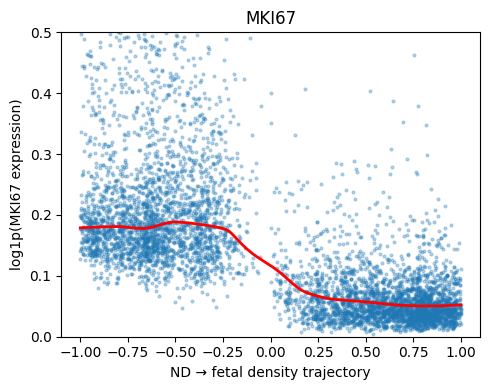

In [110]:
gene_name = "MKI67"
visualize_gene_trajectory(comparison_adata, other_state = "fetal", gene = gene_name, ylim = (0, 0.5))
ND_up_plot.savefig(plots_dir + gene_name + ".pdf")

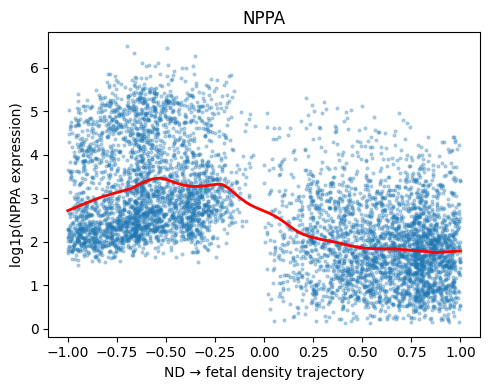

In [116]:
gene_name = "NPPA"
other_state = "fetal"
visualize_gene_trajectory(comparison_adata, other_state = "fetal", gene = gene_name)
ND_up_plot.savefig(plots_dir + gene_name + "_" + other_state + ".pdf")

#### Run disease trajectory for cardiomyocytes

In [49]:
%%time
other_group = "postnatal:DCM"
non_diseased_group = "postnatal:ND"
max_cells_per_group = 3000

DCM_comparison_adata = funcs.perform_trajectory_analysis(adata, other_group = other_group,
                                               max_cells_per_group=max_cells_per_group, non_diseased_group=non_diseased_group)
DCM_gene_traj_df = funcs.compute_gene_signatures_along_traj(DCM_comparison_adata)

Downsampling summary:
age_disease
postnatal:DCM    3000
postnatal:ND     3000
Name: count, dtype: int64
CPU times: user 58.8 s, sys: 2min 32s, total: 3min 31s
Wall time: 3min 7s


In [78]:
#DCM_gene_traj_df.tail(50)

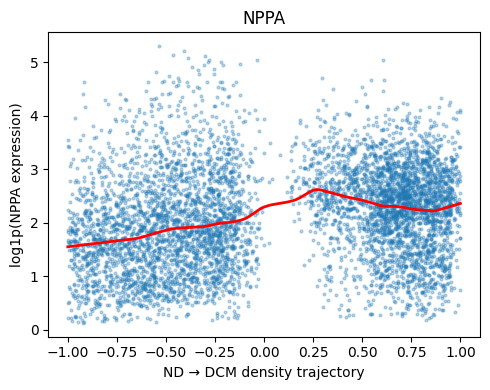

In [109]:
gene_name = "NPPA"
DCM_NPPA_plot = visualize_gene_trajectory(DCM_comparison_adata, other_state = "DCM", gene = gene_name)
DCM_NPPA_plot.savefig(plots_dir + gene_name + ".pdf")

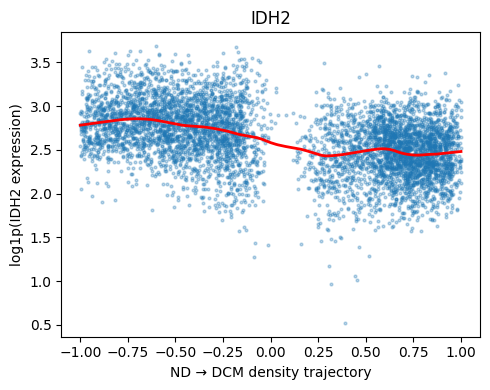

In [108]:
gene_name = "IDH2"
DCM_IDH2_plot = visualize_gene_trajectory(DCM_comparison_adata, other_state = "DCM", gene = gene_name)
DCM_IDH2_plot.savefig(plots_dir + gene_name + ".pdf")

In [77]:
%%time
other_group = "postnatal:ICM"
non_diseased_group = "postnatal:ND"
max_cells_per_group = 3000

ICM_comparison_adata = funcs.perform_trajectory_analysis(adata, other_group = other_group,
                                               max_cells_per_group=max_cells_per_group, non_diseased_group=non_diseased_group)
ICM_gene_traj_df = funcs.compute_gene_signatures_along_traj(ICM_comparison_adata)

Downsampling summary:
age_disease
postnatal:ICM    3000
postnatal:ND     3000
Name: count, dtype: int64
CPU times: user 52.1 s, sys: 1min 55s, total: 2min 47s
Wall time: 2min 22s


In [93]:
#ICM_gene_traj_df.head(60)

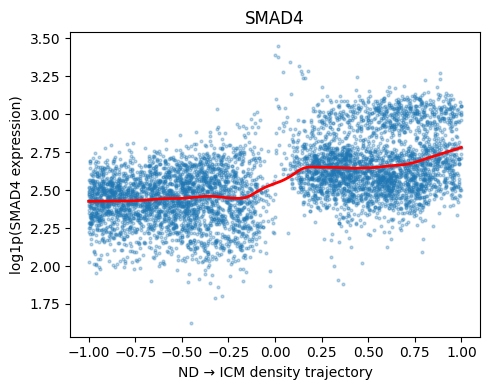

In [107]:
gene_name = "SMAD4"
ICM_SMAD4_plot = visualize_gene_trajectory(ICM_comparison_adata, other_state = "ICM", gene = gene_name)
ICM_SMAD4_plot.savefig(plots_dir + gene_name + ".pdf")

### HCM trajectory

In [91]:
%%time
other_group = "postnatal:HCM"
non_diseased_group = "postnatal:ND"
max_cells_per_group = 3000

HCM_comparison_adata = funcs.perform_trajectory_analysis(adata, other_group = other_group,
                                               max_cells_per_group=max_cells_per_group, non_diseased_group=non_diseased_group)
HCM_gene_traj_df = funcs.compute_gene_signatures_along_traj(HCM_comparison_adata)

Downsampling summary:
age_disease
postnatal:HCM    3000
postnatal:ND     3000
Name: count, dtype: int64
CPU times: user 52.9 s, sys: 2min 24s, total: 3min 17s
Wall time: 2min 53s


In [104]:
#HCM_gene_traj_df.tail(50)

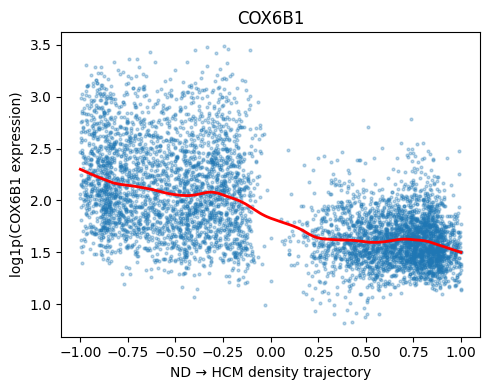

In [106]:
gene_name = "COX6B1"
HCM_SMAD4_plot = visualize_gene_trajectory(HCM_comparison_adata, other_state = "HCM", gene = gene_name)
HCM_SMAD4_plot.savefig(plots_dir + gene_name + ".pdf")